In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt

In [ ]:
fake = pd.read_csv("/content/drive/MyDrive/Fake.csv")
true = pd.read_csv("/content/drive/MyDrive/True.csv")

fake["label"] = 0
true["label"] = 1

data = pd.concat([fake, true], axis=0)

data["content"] = data["title"] + " " + data["text"]

data.drop_duplicates(subset=["content"], inplace=True)

data = data.sample(frac=1, random_state=42).reset_index(drop=True)



In [ ]:
X = data["content"]
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pickle
import os

# Paths (change if needed)
model_path_lr = "/content/drive/MyDrive/lr_model.pkl"
model_path_rf = "/content/drive/MyDrive/rf_model.pkl"
vectorizer_path = "/content/drive/MyDrive/tfidf_vectorizer.pkl"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_df=0.7,
    min_df=5,
    ngram_range=(1,2),
    max_features=10000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [ ]:
lr = LogisticRegression(
    C=1.0,
    max_iter=1000,
    n_jobs=-1
)

lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_tfidf, y_train)

y_pred_rf = rf.predict(X_test_tfidf)

In [ ]:
print("===== Logistic Regression =====")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

print("\n===== Random Forest =====")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

===== Logistic Regression =====
Accuracy: 0.9886203810254444
F1 Score: 0.9895650134834095
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      3582
           1       0.98      1.00      0.99      4239

    accuracy                           0.99      7821
   macro avg       0.99      0.99      0.99      7821
weighted avg       0.99      0.99      0.99      7821


===== Random Forest =====
Accuracy: 0.9893875463495717
F1 Score: 0.9902935329201263
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      3582
           1       0.98      1.00      0.99      4239

    accuracy                           0.99      7821
   macro avg       0.99      0.99      0.99      7821
weighted avg       0.99      0.99      0.99      7821



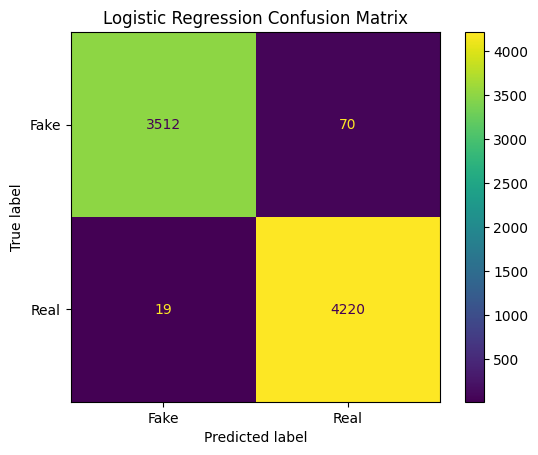

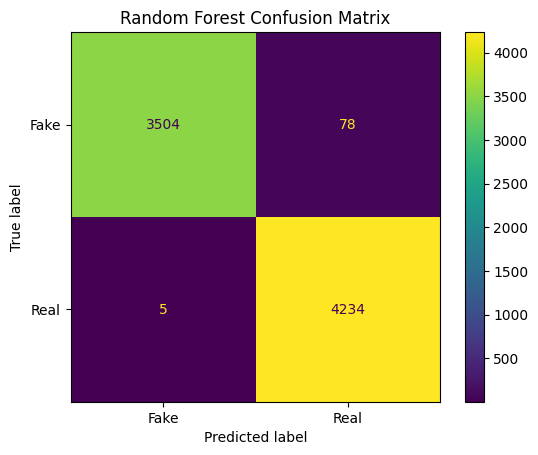

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


cm_lr = confusion_matrix(y_test, y_pred_lr)

disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=["Fake", "Real"])
disp_lr.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()



cm_rf = confusion_matrix(y_test, y_pred_rf)

disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Fake", "Real"])
disp_rf.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [ ]:
def predict_news(text):
    vec = vectorizer.transform([text])

    lr_pred = lr.predict(vec)[0]
    rf_pred = rf.predict(vec)[0]

    print("Logistic Regression:", "Real" if lr_pred else "Fake")
    print("Random Forest:", "Real" if rf_pred else "Fake")

In [ ]:
user_input = input("Enter news: ")
predict_news(user_input)